## Imports

In [3]:
import numpy as np, numpy.linalg as LA, math
from math import pi as π
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.integrate import solve_ivp

## Duffing's Equation
For an overview, see [Duffing equation](https://en.wikipedia.org/wiki/Duffing_equation)
$$
    \ddot x + \delta \dot x + \alpha x + \beta x^3 = \gamma\cos(\omega t)
$$
As a first order system
\begin{align}
    \dot x_1 &= x_2\cr
    \dot x_2 &= -\delta x_2 - x_1(\alpha+\beta x_1^2) + \gamma\cos(\omega t)\cr
\end{align}
Note the cubic stiffness term.

### Functions and parameters

In [27]:
α = -1.
β = 1.
δ = 0.25
γ = 0.30
ω = 1.00
def duffing(t,xx):
    x1,x2 = xx
    return [x2,-δ*x2-x1*(α+β*x1**2)+γ*np.cos(ω*t)]

### One intitial condion over many periods of the forcing term.

In [28]:
atol,rtol = 1e-8,1e-8
periods = 10
period = 2*π/ω
t0,t1 = 0.,periods*period
t_span = [t0,t1]
y0 = [1.,1.]
t_eval = np.linspace(t0,t1,periods*100)

In [29]:
%%time
sol = solve_ivp(duffing,t_span,y0,t_eval=t_eval,atol=atol,rtol=rtol)
sol

CPU times: user 76.8 ms, sys: 2.99 ms, total: 79.8 ms
Wall time: 78 ms


  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  6.289e-02 ...  6.277e+01  6.283e+01]
        y: [[ 1.000e+00  1.063e+00 ...  1.122e+00  1.119e+00]
            [ 1.000e+00  9.989e-01 ... -4.449e-02 -4.295e-02]]
      sol: None
 t_events: None
 y_events: None
     nfev: 4052
     njev: 0
      nlu: 0

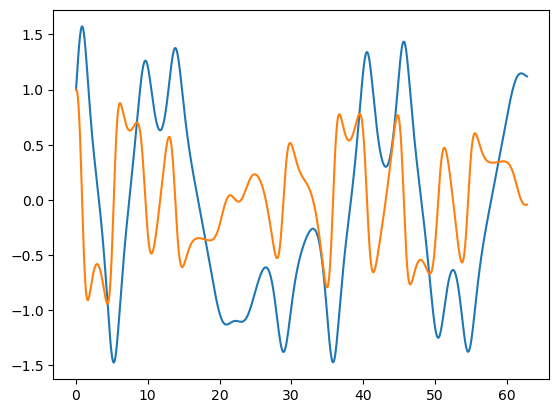

In [30]:
plt.plot(sol.t,sol.y.T)

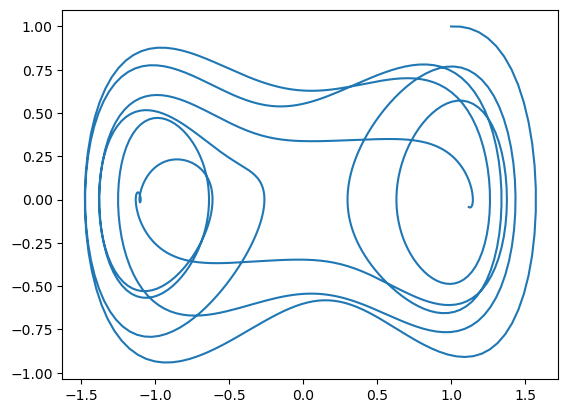

In [31]:
plt.plot(sol.y[0],sol.y[1])

In [32]:
periods = 3000
t0,t1 = 0.,periods*period
t_span = [t0,t1]
t_eval = np.linspace(t0,t1,periods*100)

In [33]:
%%time
sol = solve_ivp(duffing,t_span,y0,t_eval=t_eval,atol=atol,rtol=rtol)
sol

CPU times: user 21.3 s, sys: 74.9 ms, total: 21.4 s
Wall time: 21.5 s


  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  6.283e-02 ...  1.885e+04  1.885e+04]
        y: [[ 1.000e+00  1.063e+00 ...  7.966e-01  8.273e-01]
            [ 1.000e+00  9.989e-01 ...  4.743e-01  5.028e-01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 1154012
     njev: 0
      nlu: 0

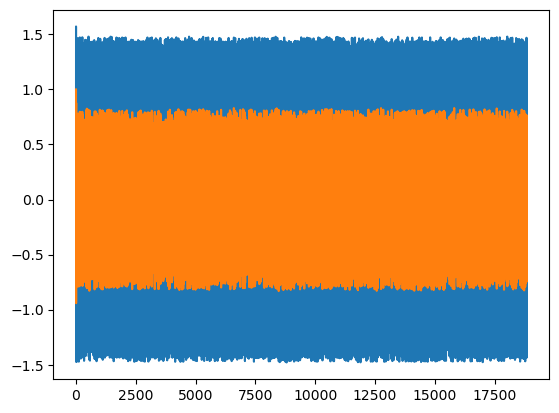

In [34]:
plt.plot(sol.t,sol.y.T)

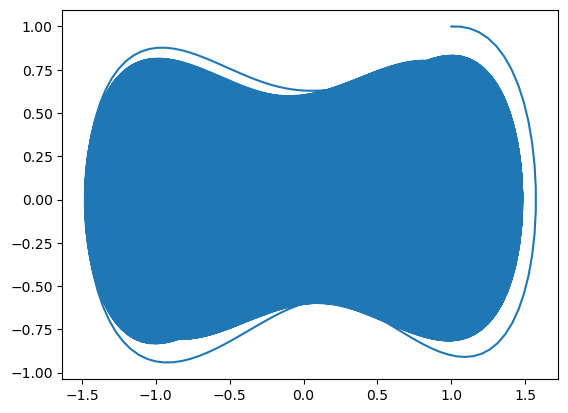

In [35]:
plt.plot(sol.y[0],sol.y[1])

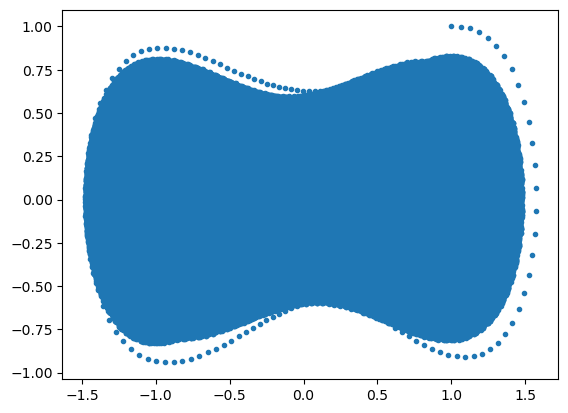

In [36]:
plt.plot(sol.y[0],sol.y[1],'.')

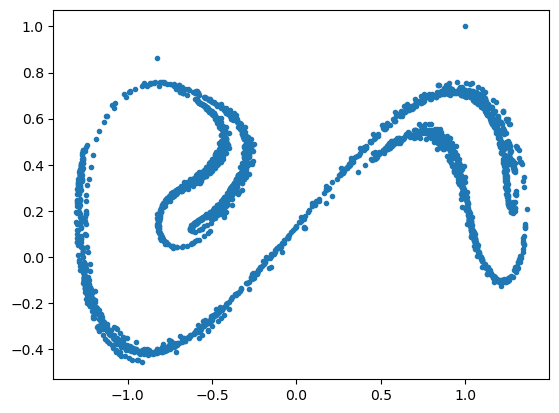

In [37]:
plt.plot(sol.y[0,::100],sol.y[1,::100],'.')

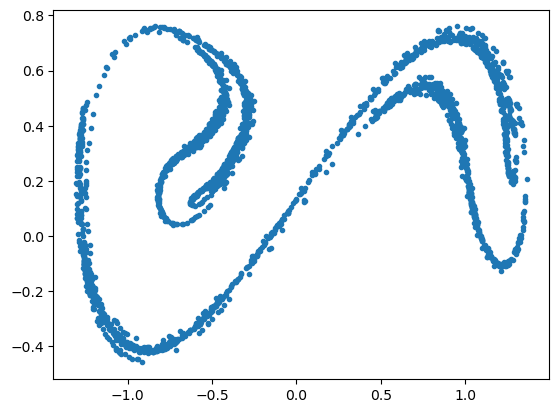

In [16]:
start = 400
plt.plot(sol.y[0,start::100],sol.y[1,start::100],'.')

In [38]:
α = 1.
β = 5.
δ = 0.02
γ = 8.
ω = 0.5

periods = 3000
period = 2*π/ω
t0,t1 = 0.,periods*period
t_span = [t0,t1]
t_eval = np.linspace(t0,t1,periods*100)

CPU times: user 1min 34s, sys: 219 ms, total: 1min 34s
Wall time: 1min 34s


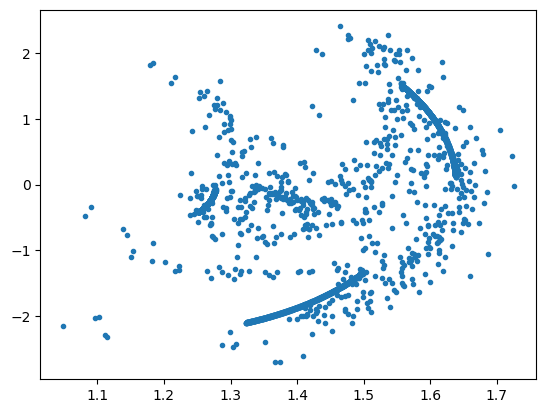

In [40]:
%time sol = solve_ivp(duffing,t_span,y0,t_eval=t_eval,atol=atol,rtol=rtol)

start = 400
plt.plot(sol.y[0,start::100],sol.y[1,start::100],'.')

In [42]:
#help(solve_ivp)

## Runge-Kutta Methods
1. [Runge–Kutta methods](https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta_methods)
2. [List of Runge–Kutta methods](https://en.wikipedia.org/wiki/List_of_Runge%E2%80%93Kutta_methods)

Butcher tableau for an **explicit** Runge-Kutta scheme 
\begin{array}
{c|ccccc}
0 \\
c_2 & a_{21}\\
c_3 & a_{31} &a_{32} \\
\vdots & \vdots & & \ddots\\
c_s& a_{s1}& a_{s2} & \cdots & a_{s,s-1}\\
\hline
& b_1 &b_2 &\cdots & b_{s-1} & b_s \\ 
\end{array}

Then
$$
    y_{n+1} = y_n+h\sum_{i=1}^{s}b_i k_i
$$

where
\begin{align}
    k_1 &= f(t_n,y_n),\cr
    k_2 &= f(t_n+c_2h,y_n+h(a_{21}k_1)),\cr
    k_3 &= f(t_n+c_3h,y_n+h(a_{31}k_1+a_{32}k_2)),\cr
    &\vdots\cr
    k_s &= f(t_n+c_sh,y_n+h(a_{s1}k_1+a_{s2}k_2+\cdots+a_{s,s-1}k_{s-1}))\cr
\end{align}

## Forward Euler Method
$$
    y_{n+1} = y_{n} + hf(t_n,y_n)
$$
for the system
$$
    \dot y = f(t,y).
$$
where $y_{n+1}$ is to be an approximation for the solution of this problem that satisfies
$$
    y(t_{n}) = y_n
$$
at time
$$
    t_{n+1} = t_n + h
$$

### Example problem
$$
    y' = -2 y,\qquad y(0) = 1.
$$
True solution
$$
    y(t) = e^{-2t}
$$

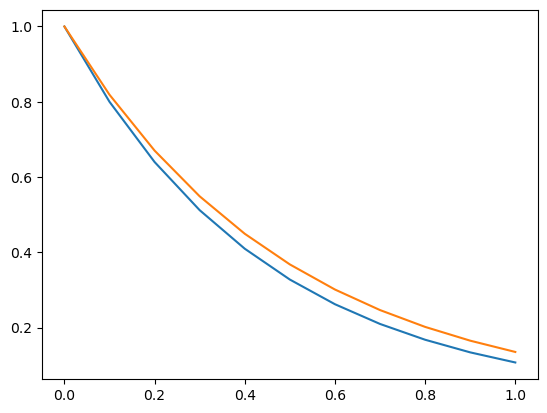

In [44]:
N = 10
t0,tN = 0,1

h = (tN-t0)/N
t = np.linspace(t0,tN,N+1)

y0 = 1.
y = [y0]

f = lambda t,y: -2*y

for tn in t[:-1]:
    yn = y[-1]
    ynp1 = yn + h*f(tn,yn)
    y.append(ynp1)

plt.plot(t,y)
plt.plot(t,np.exp(-2*t))

In [45]:
err = np.exp(-2) - y[-1]
err,err/h

(np.float64(0.02796110083661267), np.float64(0.2796110083661267))

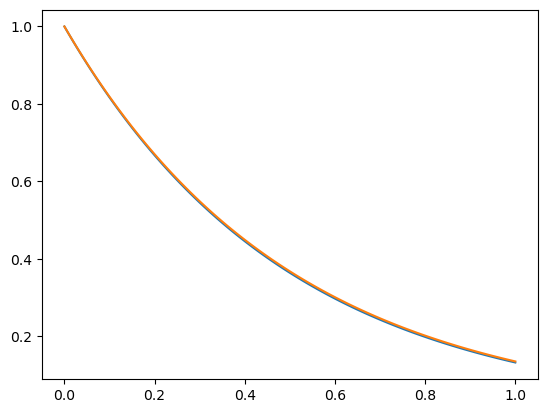

In [46]:
N = 100
t0,tN = 0,1

h = (tN-t0)/N
t = np.linspace(t0,tN,N+1)

y0 = 1.
y = [y0]

f = lambda t,y: -2*y

for tn in t[:-1]:
    yn = y[-1]
    ynp1 = yn + h*f(tn,yn)
    y.append(ynp1)

plt.plot(t,y)
plt.plot(t,np.exp(-2*t))

In [47]:
err = np.exp(-2) - y[-1]
err,err/h

(np.float64(0.002715727341859542), np.float64(0.2715727341859542))